# **Technical Report**  
### **Jiapeng Wang**  

## **Background**  

### **1. Project Overview**  
Our objective is to select the optimal USA lineup to maximize the medal count in the 2024 Women's Gymnastics Olympic Games.  

To achieve this, we utilize a comprehensive dataset, including:  
- **Tokyo 2021 Olympic results**  
- **2022-2023 international competition results** from over 40 major events, such as:  
  - World Championships (2022, 2023)  
  - European Championships (2022, 2023)  

### **2. Approach**  
I developed a **performance prediction model** that estimates each gymnast's score distribution based on historical data.  

The methodology includes:  
- Fixing the lineups of **11 competing countries**  
- Simulating **all possible USA lineups**  
- Running **2000 simulations per lineup**  
- Calculating the **average medal count**  
- Selecting the **optimal lineup** that prioritizes:  
  1. Gold medals  
  2. Silver medals  
  3. Bronze medals  


In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import KFold
from statsmodels.formula.api import mixedlm
from sklearn.metrics import mean_squared_error
from patsy import dmatrix
from sklearn.pipeline import Pipeline
from itertools import combinations
from tqdm import tqdm 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

## **Data Cleaning and Preprocessing**  

### **1. Variable Name Standardization**  
- Convert all column names to lowercase for consistency.  

### **2. Competition Round Standardization**  
- Standardize competition round naming by replacing **"AAqual"** and **"TeamQual"** with **"qual"**.  

### **3. Geographic Information Cleaning**  
- Remove periods (`.`) from the **"location"** column.  
- Standardize **"country"** codes:  
  - **GE1, GE2 → GER**  
  - **NIR → IRL**  
  - **ENG, SCO, WAL, IOM → GBR**  
  - **SIN → SGP**  
- Handle missing values (convert to NaN).  

### **4. Athlete Name Cleaning**  
- Standardize **"firstname"** and **"lastname"** formatting (capitalize the first letter, remove extra spaces).  
- Create a **"fullname"** column by merging first and last names.  

### **5. Compute Missing Penalty Values**  
- If **"penalty"** is missing, compute it as:  penalty = d_score + e_score - score

  (ensuring non-negative values).  

### **6. Standardizing Competition Locations**  
- Retain only country information, removing city prefixes.  
- Standardize region names:  
  - **Utah, Illinois, FL, CA, Kentucky, Texas → United States**  
  - **England → United Kingdom**  

### **7. Gymnastics Event Standardization**  
- Standardize event names:  
  - **"hb" → "HB"**  
  - **"VT1", "VT2" → "VT"**  

### **8. Date Format Cleaning**  
- Remove irrelevant information (e.g., day abbreviations).  
- Standardize date format to **"dd mm yyyy"**.  
- Parse and convert date values; mark unparseable entries as NaN.  


In [2]:
def clean_data(df):
    gym_data = df.copy()
    
    gym_data.columns = gym_data.columns.str.lower()
    
    gym_data['round'] = gym_data['round'].replace({ 'AAqual': 'qual', 'TeamQual': 'qual'
    }, regex=True)
    
    gym_data['location'] = gym_data['location'].str.replace(r'\.', '', regex=True)

    gym_data['country'] = gym_data['country'].replace({
        'GE1': 'GER', 'GE2': 'GER', 'NIR': 'IRL',
        'ENG': 'GBR', 'SCO': 'GBR', 'WAL': 'GBR', 'IOM': 'GBR',
        'SIN': 'SGP', '': np.nan
    }, regex=True)
    
    gym_data['firstname'] = gym_data['firstname'].str.title().str.strip()
    gym_data['lastname'] = gym_data['lastname'].str.title().str.strip()
    
    gym_data['fullname'] = (gym_data['firstname'] + ' ' + gym_data['lastname']).str.strip()
    
    # Calculate NA penalty values
    mask = gym_data['penalty'].isna()
    gym_data.loc[mask, 'penalty'] = np.maximum(0, 
        np.round(gym_data.loc[mask, 'd_score'] + gym_data.loc[mask, 'e_score'] - gym_data.loc[mask, 'score'], 3))
    
    # Filter competition locations to country
    gym_data['location'] = gym_data['location'].str.replace(r'.*, ', '', regex=True)
    gym_data['location'] = gym_data['location'].replace({
        'Utah': 'United States', 'Illinois': 'United States', 'FL': 'United States', 
        'CA': 'United States', 'Kentucky': 'United States', 'Texas': 'United States',
        'England': 'United Kingdom'
    }, regex=True)
    
    gym_data['apparatus'] = gym_data['apparatus'].replace({
        'hb': 'HB', 'VT1': 'VT', 'VT2': 'VT'
    }, regex=True)

    gym_data['date'] = gym_data['date'].str.replace(r'sun|thu', '', regex=True, case=False)
    gym_data['date'] = gym_data['date'].str.replace(r'.*-', '', regex=True)
    gym_data['date'] = gym_data['date'].str.title().str.strip()
    gym_data['date'] = gym_data['date'].replace({
        'June': 'Jun', 'July': 'Jul', 'Sept': 'Sep', ',': ''
    }, regex=True)

    def parse_date(date_str):
        try:
            return datetime.strptime(date_str, "%d %b %Y").date()
        except:
            try:
                return datetime.strptime(date_str, "%d %B %Y").date()
            except:
                return np.nan

    gym_data['date'] = gym_data['date'].apply(parse_date)

    if gym_data['date'].isna().any():
        print("Warning: dates may not have processed properly. Some dates now NA.")
        gym_data = gym_data.drop_duplicates()
    
    return gym_data

df_old = pd.read_csv('data_2017_2021.csv')
df_new = pd.read_csv('data_2022_2023.csv')

df_old = clean_data(df_old)
df_new = clean_data(df_new)


### **9. Filtering Target Countries**  
- Keep only athlete data from the following countries:  
  - **USA, GBR, CAN, BRA, FRA, CHN, JPN, NED, ITA, AUS, ROU, KOR**  

### **10. Athlete Name and Gender Correction**  
- Standardize full names for specific athletes, including:  
  - **"Aiden Frick" → "Aiden Michael Frick"**  
  - **"Max Whitlock" → "Max Whitlock Obe"**  
  - **"Ellie Black" → "Elsabeth Black"**  
- Correct gender labels (`gender = "w"`) for female athletes such as:  
  - **Emily Whitehead**  
  - **Emma Spence**  
  - **Jenna Lalonde**  
- Resolve inconsistent name formats for the same athlete, such as:  
  - **"Bernardo Miranda" → "Bernardo Actos Miranda"**  
  - **"Melanie Jesus Santos" → "Melanie De Jesus Dos Santos"**  
  - **"Lucas Souza Bitencourt" → "Lucas De Souza Bitencourt"**  



In [3]:
target_countries = ['USA', 'GBR', 'CAN', 'BRA', 'FRA', 'CHN', 'JPN', 'NED', 'ITA', 'AUS', 'ROU', 'KOR']

df_old = df_old[df_old['country'].isin(target_countries)]
df_new = df_new[df_new['country'].isin(target_countries)]

In [4]:
df_new.loc[df_new['fullname'] == "Aiden Frick", 'fullname'] = "Aiden Michael Frick"

df_new.loc[df_new['fullname'] == "Clay Masonstephens", 'fullname'] = "Clay Mason Stephens"

df_new.loc[df_new['fullname'] == "Emily Whitehead", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Georgia Godwin", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Kiplin Smith", 'fullname'] = "Kiplin Morrish Smith"


df_new.loc[df_new['fullname'] == "Cassandra Lee", 'fullname'] = "Cassandra Paige Lee"

df_new.loc[df_new['fullname'] == "Ellie Black", 'fullname'] = "Elsabeth Black"

df_new.loc[df_new['fullname'] == "Emma Spence", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Jenna Lalonde", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Laurie Denommée", 'fullname'] = "Laurie Denommee"
df_new.loc[df_new['fullname'] == "Laurie Denommee", 'gender'] = "w"

df_new.loc[df_new['fullname'] == "Sam Zakutney", 'fullname'] = "Samuel Zakutney"

df_new.loc[df_new['fullname'] == "Sydney Turner", 'fullname'] = "Sydney Leslie Turner"

df_new.loc[df_new['fullname'] == "Zachary Clay", 'fullname'] = "Zachary Nathaniel Clay"

mask_bernardo = (
    (df_new['fullname'] == "Bernardo Actos Andrade De Souza Miranda") |
    (df_new['fullname'] == "Bernardo Miranda")
)
df_new.loc[mask_bernardo, 'fullname'] = "Bernardo Actos Miranda"

df_new.loc[df_new['fullname'] == "Carolyne Pedro", 'fullname'] = "Carolyne Mercer Winche Pedro"

df_new.loc[df_new['fullname'] == "Julia Soares", 'fullname'] = "Julia Das Neves Botega Soares"

mask_lucas = (
    (df_new['fullname'] == "Lucas Souza Bitencourt") |
    (df_new['fullname'] == "Lucas Bitencourt")
)
df_new.loc[mask_lucas, 'fullname'] = "Lucas De Souza Bitencourt"

df_new.loc[df_new['fullname'] == "Luisa Maia", 'fullname'] = "Luisa Gomes Maia"

mask_patrick = (
    (df_new['fullname'] == "Patrick Correa") |
    (df_new['fullname'] == "Patrick Sampaio")
)
df_new.loc[mask_patrick, 'fullname'] = "Patrick Sampaio Correa"

df_new.loc[df_new['fullname'] == "Tomas Florencio", 'fullname'] = "Tomas Rodrigues Florencio"

df_new.loc[df_new['fullname'] == "Yuri Guimarães", 'fullname'] = "Yuri Guimaraes"

df_new.loc[df_new['fullname'] == "Max Whitlock", 'fullname'] = "Max Whitlock Obe"
df_new.loc[df_new['fullname'] == "Pavel Karenejenko", 'fullname'] = "Pavel Karnejenko"
df_new.loc[df_new['fullname'] == "Poppy Stickler", 'fullname'] = "Poppy Grace Stickler"
df_new.loc[df_new['fullname'] == "Ruby Evan", 'fullname'] = "Ruby Evans"

gbr_female_athletes = [
    "Alice Kinsella", "Cara Kennedy", "Eilidh Gorrell", "Emily Bremner",
    "Georgia Mae Fenton", "Jea Maracha", "Mia Evans", "Ondine Achampong",
    "Poppy Grace Stickler", "Shannon Archer", "Tara Donnelly"
]
for name in gbr_female_athletes:
    df_new.loc[df_new['fullname'] == name, 'gender'] = "w"


df_new.loc[df_new['fullname'] == "Léa Franceries", 'fullname'] = "Lea Franceries"
df_new.loc[df_new['fullname'] == "Léo Saladino", 'fullname'] = "Leo Saladino"

mask_melanie = (
    (df_new['fullname'] == "Mélanie De Jesus Dos Santos") |
    (df_new['fullname'] == "Melanie Jesus Santos")
)
df_new.loc[mask_melanie, 'fullname'] = "Melanie De Jesus Dos Santos"


df_new.loc[df_new['fullname'] == "Morgane Osyssek", 'fullname'] = "Morgane Osyssek Reimer"


df_new.loc[df_new['fullname'] == "Garam Bae", 'fullname'] = "Ga-Ram Bae"
df_new.loc[df_new['fullname'] == "Jinseong Yun", 'fullname'] = "Jin-Seong Yun"
df_new.loc[df_new['fullname'] == "Yoseop Jeon", 'fullname'] = "Yo-Seop Jeon"



df_new.loc[df_new['fullname'] == "Jermain Grünberg", 'fullname'] = "Jermain Gruenberg"
df_new.loc[df_new['fullname'] == "Loran Munck", 'fullname'] = "Loran De Munck"
df_new.loc[df_new['fullname'] == "Martijn Veer", 'fullname'] = "Martijn De Veer"
df_new.loc[df_new['fullname'] == "Tisha Volleman", 'fullname'] = "Tisha Manouk Gijs Volleman"
df_new.loc[df_new['fullname'] == "Vera Pol", 'fullname'] = "Vera Van Pol"
df_new.loc[df_new['fullname'] == "Wout Teillers", 'fullname'] = "Wout Johan Alexander Teillers"



df_new.loc[df_new['fullname'] == "Andrei Muntean", 'fullname'] = "Andrei Vasile Muntean"


df_new.loc[df_new['fullname'] == "Razvan Denis Marc", 'fullname'] = "Razvan-Denis Marc"

mask_toma = (
    (df_new['fullname'] == "Toma Roland Modoianu Zseder") |
    (df_new['fullname'] == "Toma Modoianu-Zseder") |
    (df_new['fullname'] == "Toma Modoianu Zseder")
)
df_new.loc[mask_toma, 'fullname'] = "Toma Roland Modoianu-Zseder"



df_new.loc[df_new['fullname'] == "Curran Phillips", 'fullname'] = "Curran Michael Phillips"
df_new.loc[df_new['fullname'] == "Ian Skirkey", 'fullname'] = "Ian Hunter Skirkey"
df_new.loc[df_new['fullname'] == "Joscelyn Roberson", 'fullname'] = "Joscelyn Michelle Roberson"
df_new.loc[df_new['fullname'] == "Joshua Karnes", 'fullname'] = "Joshua Andrew Karnes"
df_new.loc[df_new['fullname'] == "Khoi Young", 'fullname'] = "Khoi Alexander Young"
df_new.loc[df_new['fullname'] == "Matt Cormier", 'fullname'] = "Matthew Cormier"
df_new.loc[df_new['fullname'] == "Nola Matthews", 'fullname'] = "Nola Rhianne Matthews"
df_new.loc[df_new['fullname'] == "Shane Wiskus", 'fullname'] = "Shane Michael Wiskus"
df_new.loc[df_new['fullname'] == "Taylor Christopulos", 'fullname'] = "Taylor Troy Christopulos"
df_new.loc[df_new['fullname'] == "Yul Moldauer", 'fullname'] = "Yul Kyung Tae Moldauer"

mask_fred = (
    (df_new['fullname'] == "Frederick Richard") |
    (df_new['fullname'] == "Fred Richard")
)
df_new.loc[mask_fred, 'fullname'] = "Frederick Nathaniel Richard"

In [5]:
df_old = df_old[df_old["gender"] == "w"]
df_new = df_new[df_new["gender"] == "w"]


### **11. Feature Engineering and Data Transformation**  
- **Standardize numeric values** using `StandardScaler`.  
- **Convert date columns to datetime format** to ensure consistency.  
- **Calculate the number of days before the event** to track preparation time.  
- **Compute the average score per gymnast** to analyze performance.  
- **Filter only female athletes** for gender-specific analysis.  
- **Select relevant features**:  
  - **country, round, apparatus, location, score, fullname, days_before_event, fullname_mean**  
- **Drop missing values** to ensure data quality.  

These data cleaning and transformation steps ensure a consistent, structured dataset for further modeling and analysis.  


In [6]:
df_new['date'] = pd.to_datetime(df_new['date'])
df_old['date'] = pd.to_datetime(df_old['date'])
df_new['days_before_event'] = (pd.to_datetime('2024-07-25') - df_new['date']).dt.days
df_old['days_before_event'] = (pd.to_datetime('2024-07-25') - df_old['date']).dt.days
df_new['fullname_mean'] = df_new.groupby('fullname')['score'].transform('mean')
df_old['fullname_mean'] = df_old.groupby('fullname')['score'].transform('mean')                                                           

In [7]:
selected_feature = ['country', 'round', 'apparatus', 'location', 'score', 'fullname', 'days_before_event', 'fullname_mean']

df_new = df_new[selected_feature]
df_old = df_old[selected_feature]
df_old = df_old.dropna()

In [8]:
scaler = StandardScaler()

df_new['days_before_event'] = scaler.fit_transform(df_new[['days_before_event']])
df_old['days_before_event'] = scaler.fit_transform(df_old[['days_before_event']])

## **Modeling Approach**  

### **1. Model Selection**  
In this study, I tested three different models to predict gymnastics scores:  
- **Linear Regression**  
- **Random Forest Regressor**  
- **Baseline Model (Mean Prediction)**  

The goal was to identify the most effective model for score prediction based on Root Mean Squared Error (RMSE) and computational efficiency.  

### **2. Feature Engineering & Data Splitting**  
The dataset includes both categorical and numerical features. The selected features are:  
- **Categorical Features**: round, apparatus, location  
- **Numerical Features**: days_before_event, fullname_mean  

The dataset was split into training and testing sets, using **80% for training and 20% for testing**.  

### **3. Data Preprocessing**  
To prepare the data for modeling:  
- **One-hot encoding** was applied to categorical features.  
- **Numerical features** were kept unchanged using passthrough.  
- A **ColumnTransformer** was used to ensure proper preprocessing.  

### **4. Model Training & Evaluation**  

#### **Linear Regression Model**  
A pipeline was constructed with the preprocessor followed by a **Linear Regression** model. After training, RMSE was calculated to evaluate the model’s performance.  

#### **Baseline Model**  
A simple baseline model was created by predicting the mean score from the training set for each gymnast. This provided a reference point for model comparison.  

#### **Random Forest Regressor**  
A **Random Forest Regressor** was also trained using the same preprocessing pipeline, with **100 estimators** to compare its predictive power against linear regression.  

### **5. Model Comparison & Selection**  
The RMSE values for each model were computed:  
- **Linear Regression RMSE**: Lower than the baseline, indicating effective learning from the data.  
- **Baseline Model RMSE**: Higher, as it only predicts the mean score.  
- **Random Forest RMSE**: Higher than Linear Regression, suggesting overfitting due to complexity.  

Since **Linear Regression** performed the best in terms of **lower RMSE** and **faster training speed**, it was selected for further analysis and simulation.  


In [9]:
df = df_new

In [10]:
features = ['round', 'apparatus', 'location', 'days_before_event', 'fullname_mean']
target = 'score'

# Split the data, using 80% for training and 20% for testing
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define categorical and numerical features
categorical_features = ['round', 'apparatus', 'location']
numeric_features = ['days_before_event', 'fullname_mean']

# Construct the preprocessor, applying one-hot encoding to categorical variables and passing through numerical data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Build the pipeline model, with the preprocessor followed by linear regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

# Make predictions and calculate RMSE
y_pred = model.predict(X_test)
rmse_model = np.sqrt(mean_squared_error(y_test, y_pred))
print("Linear Regression RMSE:", rmse_model)

# Baseline model: Predict using the mean of 'score' from the training set
mean_score = X_test['fullname_mean']
baseline_pred = np.full_like(y_test, mean_score, dtype=float)
rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline Model (Mean Prediction) RMSE:", rmse_baseline)

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the Random Forest model
model_rf.fit(X_train, y_train)

# Make predictions and calculate RMSE
y_pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 0.6880885377107907
Baseline Model (Mean Prediction) RMSE: 0.7496744692681299
Random Forest RMSE: 0.70858073491136


### **6. Residual Analysis**  
To verify that the assumptions of the linear model were met, a **residual plot** was created:  
- The residuals were centered around zero.  
- There was no clear pattern, suggesting that the linear model’s assumptions were valid.  

### **7. Feature Importance Analysis**  
The coefficients of the **Linear Regression** model were extracted to analyze feature importance. The absolute values of the coefficients were ranked to determine which features had the most influence on the score prediction.  

The modeling approach successfully identified **Linear Regression** as the optimal model for predicting gymnastics scores, providing a solid foundation for simulation.  


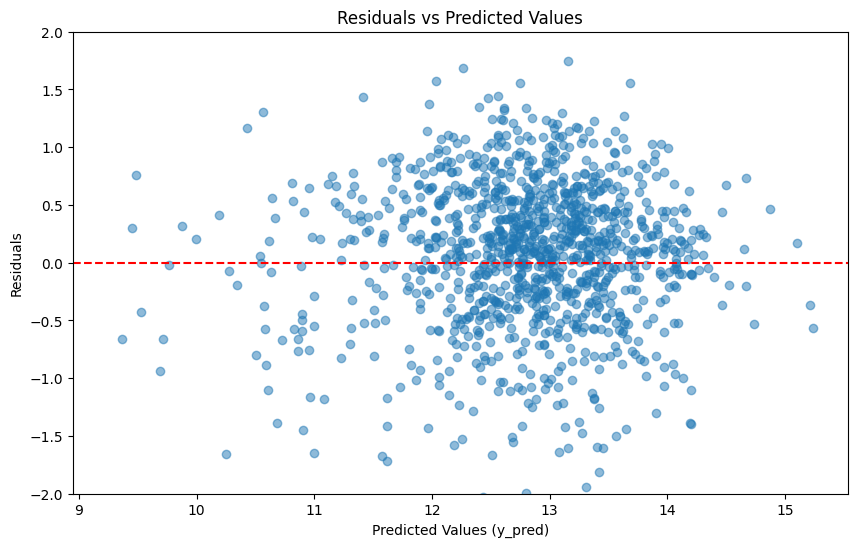

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.ylim(-2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

In [12]:
cat_feature_names = model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([cat_feature_names, numeric_features])

coefs = model.named_steps['regressor'].coef_

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
})

feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)
print(feature_importance)

                    feature  coefficient  abs_coefficient
27            fullname_mean     0.958685         0.958685
7              apparatus_VT     0.467532         0.467532
4              apparatus_BB    -0.356576         0.356576
22        location_Slovenia     0.317358         0.317358
16          location_France    -0.260103         0.260103
19          location_Israel    -0.235973         0.235973
15           location_Egypt    -0.223087         0.223087
11           location_Chile     0.161565         0.161565
14         location_Croatia    -0.153761         0.153761
13        location_Colombia     0.151164         0.151164
21       location_Singapore     0.116389         0.116389
0             round_AAfinal    -0.105562         0.105562
2               round_final     0.100746         0.100746
5              apparatus_FX    -0.076174         0.076174
8       location_Azerbaijan    -0.066670         0.066670
9          location_Belgium     0.054247         0.054247
10        loca

In [13]:
features = ['round', 'apparatus', 'location', 'days_before_event', 'fullname_mean']
target = 'score'

X = df[features]
y = df[target]

categorical_features = ['round', 'apparatus', 'location']
numeric_features = ['days_before_event', 'fullname_mean']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
# ])

model.fit(X, y)

y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

residual_std = np.std(y - y_pred)


RMSE: 0.7098691770032431


## **Simulation Process**  

### **Step 1: Fix Lineups of 12 Countries**  
I selected the top 5 gymnasts from each country based on historical performance. The countries included in the simulation are:  

In [14]:
teams = {
#         'USA': ['Simone Biles',
#                 'Shilese Jones',
#                 'Konnor Mcclain',
#                 'Skye Blakely',
#                 'Jordan Chiles'],
        'GBR': ['Jessica Gadirova',
                'Alice Kinsella',
                'Ondine Achampong',
                'Georgia Mae Fenton',
                'Rebecca Downie'],
        'CAN': ['Elsabeth Black',
                'Emma Spence',
                'Aurelie Tran',
                'Sydney Leslie Turner',
                'Ava Stewart'],
        'BRA': ['Rebeca Andrade',
                'Flavia Saraiva',
                'Jade Barbosa',
                'Julia Das Neves Botega Soares',
                'Carolyne Mercer Winche Pedro'],
        'FRA': ['Melanie De Jesus Dos Santos',
                'Carolann Heduit',
                'Marine Boyer',
                'Aline Friess',
                'Morgane Osyssek Reimer'],
        'JPN': ['Shoko Miyata',
                'Ayaka Sakaguchi',
                'Rina Kishi',
                'Mana Okamura',
                'Chiharu Yamada'],
        'NED': ['Naomi Visser',
                'Eythora Thorsdottir',
                'Vera Van Pol',
                'Tisha Manouk Gijs Volleman',
                'Sanna Veerman'],
        'ITA': ['Alice D Amato',
                'Asia D Amato',
                'Martina Maggio',
                'Elisa Iorio',
                'Manila Esposito'],
        'AUS': ['Georgia Godwin',
                'Romi Brown',
                'Ruby Pass',
                'Emily Whitehead',
                'Macy Pegoli'],
        'ROU': ['Ana Barbosu',
                'Sabrina Maneca Voinea',
                'Amalia Ghigoarta',
                'Ioana Stanciulescu',
                'Andreea Preda'],
        'KOR': ['Yunseo Lee',
                'Seojeong Yeo',
                'Solyi Shin',
                'Dohyun Eom',
                'Dayeong Lee'],
        'CHN':['Zhuofan Huang', 'Ran Wu', 'Xiaoyuan Wei', 'Yaqin Zhou', 'Qiyuan Qiu']
    
}

select_country = 'USA'

### **Step 2: Predict Performance**  
Each gymnast’s performance was predicted based on historical scores. To ensure realistic variability, random noise was introduced to simulate competition fluctuations.  

In [15]:
df = df[
    (df['country'] == select_country) |
    (df.apply(lambda row: (row['country'] in teams) and (row['fullname'] in teams[row['country']]), axis=1))
]

fullname_dict = dict(zip(df['fullname'], df['fullname_mean']))

pred_teamfinal = {}
pred_AAfinal = {}
pred_final = {}
pred_qual = {}


for idx, row in df.iterrows():
    athlete = row['fullname']
    app = row['apparatus']
    key = f"{athlete}_{app}" 

    
    input_df_teamfinal = pd.DataFrame({
        'round': ['TeamFinal'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_teamfinal[key] = model.predict(input_df_teamfinal)[0]

    
    input_df_AAfinal = pd.DataFrame({
        'round': ['AAfinal'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_AAfinal[key] = model.predict(input_df_AAfinal)[0]

    input_df_final = pd.DataFrame({
        'round': ['final'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_final[key] = model.predict(input_df_final)[0]

    input_df_qual = pd.DataFrame({
        'round': ['qual'],
        'apparatus': [app],
        'location': ['France'],
        'days_before_event': [0],
        'fullname_mean': [fullname_dict.get(athlete)]
    })
    pred_qual[key] = model.predict(input_df_qual)[0]


In [16]:
def get_predicted_score(fullname, apparatus, round_, seed=None): 
    """
    Get the predicted score based on the athlete's fullname, apparatus, and round_, with added random noise.
    
    Parameters:
        fullname: Athlete's name (string)
        apparatus: Apparatus (string)
        round_: Round (string), supports 'TeamFinal', 'AAfinal', 'final', 'qual'
    
    Returns:
        Predicted score with noise added (float). Returns 0 if the corresponding predicted score is not found.
    """

    if seed is not None:
        np.random.seed(seed)
    
    key = f"{fullname}_{apparatus}"
    
    # Select the corresponding dictionary based on round_
    pred_dicts = {
        'TeamFinal': pred_teamfinal,
        'AAfinal': pred_AAfinal,
        'final': pred_final,
        'qual': pred_qual
    }
    
    if round_ not in pred_dicts:
        raise ValueError(f"Unsupported round: {round_}")
    
    base_score = pred_dicts[round_].get(key)
    if base_score is None:
        # If no corresponding predicted score is found, return 0
        return 0.0

    noise = np.random.normal(loc=0, scale=0.7)
    return base_score + noise

In [17]:
df_select = df[df['country'] == select_country]

df_avg = df_select.groupby('fullname')['score'].mean().reset_index()
df_avg = df_avg.sort_values(by='score', ascending=False)
top10 = df_avg.head(10)['fullname'].tolist()

print("Top 10 athletes from qualification round:", top10)

Top 10 athletes from qualification round: ['Simone Biles', 'Shilese Jones', 'Konnor Mcclain', 'Sunisa Lee', 'Jade Carey', 'Jordan Chiles', 'Skye Blakely', 'Leanne Wong', 'Olivia Greaves', 'Kayla Dicello']


### **Step 3: USA Lineup Simulation**  
I simulated all possible USA team lineups and ran a complete competition process, following Olympic gymnastics rules:  

- **Qualification Round (5-4-3 Rule)**:  
  - Each team consists of 5 gymnasts.  
  - 4 gymnasts compete on each apparatus, and the top 3 scores count.  

- **Team Final (5-3-3 Rule)**:  
  - Only 3 gymnasts compete per event.  
  - All scores count toward the team total.  

- **Individual All-Around (AA) Final**:  
  - The top 24 gymnasts from qualifications (maximum 2 per country) advance.  
  - These gymnasts compete across all apparatus for the all-around title.  

- **Event Finals (VT, UB, BB, FX)**:  
  - The top 8 qualifiers per event (maximum 2 per country) compete.  
  - Scores from this round determine individual event medalists.  

By simulating these competitions, I aimed to determine the optimal lineup strategy for Team USA at the **2024 Olympics**.  

In [18]:
foreign_athletes = teams


apparatuses = ['VT', 'UB', 'BB', 'FX']

# ----------------= Simulation Functions -----------------
def simulate_qualification(qual_athletes):
    qual_scores = {}
    for country, athletes in qual_athletes.items():
        qual_scores[country] = {}
        for athlete in athletes:
            qual_scores[country][athlete] = {}
            for app in apparatuses:
                # Directly call the get_predicted_score function, specifying round as 'qual'
                score = get_predicted_score(athlete, app, 'qual')
                qual_scores[country][athlete][app] = score
    return qual_scores

def determine_qualifiers(qual_scores):
    """
    Determine the qualifiers based on the qualification scores, and return three qualification lists:
      - team_qualifiers: Team qualification, format [(country, team_score), ...], sorted by team_score in descending order, top 8
      - aa_qualifiers: All-around qualification, format [(country, athlete, total_score), ...], max 2 per country, top 24 overall
      - event_qualifiers: Event qualification, format { apparatus: [(country, athlete, score), ...] }, top 8 for each event
    """
    # (1) Team qualification: The total score of each country's team = sum of the top 3 scores in each event
    team_scores = {}
    for country, athletes in qual_scores.items():
        total = 0.0
        for app in apparatuses:
            scores = []
            for athlete, scores_dict in athletes.items():
                scores.append(scores_dict.get(app, 0))
            scores = sorted(scores, reverse=True)
            top3 = scores[:3]  
            total += sum(top3)
        team_scores[country] = total
    team_qualifiers = sorted(team_scores.items(), key=lambda x: x[1], reverse=True)[:8]
    
    aa_list = []
    for country, athletes in qual_scores.items():
        for athlete, scores_dict in athletes.items():
            total = sum(scores_dict.get(app, 0) for app in apparatuses)
            aa_list.append((country, athlete, total))
    aa_sorted = sorted(aa_list, key=lambda x: x[2], reverse=True)
    aa_qualifiers = []
    country_count = {}
    for country, athlete, total in aa_sorted:
        if country_count.get(country, 0) < 2:
            aa_qualifiers.append((country, athlete, total))
            country_count[country] = country_count.get(country, 0) + 1
        if len(aa_qualifiers) >= 24:
            break
            
    # (3) Event qualification: Top 8 for each event
    event_qualifiers = {app: [] for app in apparatuses}
    for app in apparatuses:
        app_list = []
        for country, athletes in qual_scores.items():
            for athlete, scores_dict in athletes.items():
                app_list.append((country, athlete, scores_dict.get(app, 0)))
        event_qualifiers[app] = sorted(app_list, key=lambda x: x[2], reverse=True)[:8]
    
    return team_qualifiers, aa_qualifiers, event_qualifiers

def simulate_team_finals(teams_final):
    team_final_scores = {}
    for country, athletes in teams_final.items():
        total_score = 0.0
        for app in apparatuses:
            # First get each athlete's base predicted score for the TeamFinal round from the base prediction dictionary
            athlete_base_scores = []
            for athlete in athletes:
                key = f"{athlete}_{app}"
                base_score = pred_teamfinal.get(key)
                if base_score is not None:
                    athlete_base_scores.append((athlete, base_score))
            # If no data is available for this event, skip it
            if not athlete_base_scores:
                continue
            # Sort by base predicted scores in descending order and select the top three
            athlete_base_scores.sort(key=lambda x: x[1], reverse=True)
            selected_athletes = [athlete for athlete, _ in athlete_base_scores[:3]]
            
            # For the selected athletes, call get_predicted_score to simulate actual competition scores (considering noise)
            apparatus_score = 0.0
            for athlete in selected_athletes:
                simulated_score = get_predicted_score(athlete, app, 'TeamFinal')
                apparatus_score += simulated_score
            total_score += apparatus_score
        team_final_scores[country] = total_score
    return team_final_scores

def simulate_aa_finals(aa_qualifiers):
    aa_final_scores = []
    for country, athlete, _ in aa_qualifiers:
        total = 0.0
        for app in apparatuses:
            # Directly call get_predicted_score, specifying round as 'AAfinal'
            total += get_predicted_score(athlete, app, 'AAfinal')
        aa_final_scores.append((country, athlete, total))
    return sorted(aa_final_scores, key=lambda x: x[2], reverse=True)

def simulate_event_finals(event_qualifiers):
    event_final_results = {}
    for app, qualifiers in event_qualifiers.items():
        scores_list = []
        for country, athlete, _ in qualifiers:
            # Directly call get_predicted_score, specifying round as 'final'
            score = get_predicted_score(athlete, app, 'final')
            scores_list.append((country, athlete, score))
        event_final_results[app] = sorted(scores_list, key=lambda x: x[2], reverse=True)
    return event_final_results


In [19]:
def run_simulation(selected_team):
    """
    A complete simulation process:
      1. Construct the list of athletes for all countries.
      2. Simulate the qualification scores and determine the qualifiers based on the scores.
      3. Simulate the finals (team, all-around, and event), and determine the medals based on the rankings.
      4. Return the number of medals won in each final event in this round, structured as:
         {
           'overall': {'gold': X, 'silver': Y, 'bronze': Z},  # Total for all events
           'team_final': {'gold':0/1, 'silver':0/1, 'bronze':0/1},
           'aa_final': {'gold':0/1, 'silver':0/1, 'bronze':0/1},
           'event_final': {
               app1: {'gold':0/1, 'silver':0/1, 'bronze':0/1},
               app2: {'gold':0/1, 'silver':0/1, 'bronze':0/1},
               ...
           }
         }
    """
    
    qual_athletes = {}
    qual_athletes[select_country] = list(selected_team)
    for country, ath_list in foreign_athletes.items():
        qual_athletes[country] = ath_list

    # Simulate qualification scores
    qual_scores = simulate_qualification(qual_athletes)
    # Determine the qualifiers based on the qualification scores
    team_qualifiers, aa_qualifiers, event_qualifiers = determine_qualifiers(qual_scores)

    # ---------------- Team Finals ----------------
    # The Chinese team's final roster is fixed as selected_team; other countries use all athletes from qualification
    teams_final = {}
    for country, _ in team_qualifiers:
        if country == select_country:
            teams_final[country] = list(selected_team)
        else:
            teams_final[country] = list(qual_scores[country].keys())
    team_final_scores = simulate_team_finals(teams_final)
    sorted_team_final = sorted(team_final_scores.items(), key=lambda x: x[1], reverse=True)
    team_medals = {}
    for i, (country, score) in enumerate(sorted_team_final[:3]):
        if i == 0:
            team_medals[country] = 'gold'
        elif i == 1:
            team_medals[country] = 'silver'
        elif i == 2:
            team_medals[country] = 'bronze'
    # Record the medals won by the Chinese team in the team finals (only one medal per round)
    team_final_medals = {'gold': 0, 'silver': 0, 'bronze': 0}
    if select_country in team_medals:
        team_final_medals[team_medals[select_country]] = 1

    # ---------------- Individual All-Around Finals ----------------
    aa_final = simulate_aa_finals(aa_qualifiers)
    aa_medals = {}
    for i, (country, athlete, score) in enumerate(aa_final[:3]):
        if i == 0:
            aa_medals[(country, athlete)] = 'gold'
        elif i == 1:
            aa_medals[(country, athlete)] = 'silver'
        elif i == 2:
            aa_medals[(country, athlete)] = 'bronze'
    aa_final_medals = {'gold': 0, 'silver': 0, 'bronze': 0}
    for (country, athlete), medal in aa_medals.items():
        if country == select_country:
            aa_final_medals[medal] = 1  

    # ---------------- Event Finals ----------------
    event_final = simulate_event_finals(event_qualifiers)
    event_medals = {}
    for app, results in event_final.items():
        medals = {}
        for i, (country, athlete, score) in enumerate(results[:3]):
            if i == 0:
                medals[(country, athlete)] = 'gold'
            elif i == 1:
                medals[(country, athlete)] = 'silver'
            elif i == 2:
                medals[(country, athlete)] = 'bronze'
        event_medals[app] = medals
    event_final_medals = {}
    for app, medals in event_medals.items():
        event_final_medals[app] = {'gold': 0, 'silver': 0, 'bronze': 0}
        for (country, athlete), medal in medals.items():
            if country == select_country:
                event_final_medals[app][medal] = 1

    # ---------------- Calculate Total Medals ----------------
    overall = {'gold': 0, 'silver': 0, 'bronze': 0}
    for medal in overall:
        overall[medal] = team_final_medals[medal] + aa_final_medals[medal]
        # Accumulate medals from all events
        for app in event_final_medals:
            overall[medal] += event_final_medals[app][medal]

    return {
        'overall': overall,
        'team_final': team_final_medals,
        'aa_final': aa_final_medals,
        'event_final': event_final_medals
    }


In [20]:
def simulate_for_candidate(selected_team, num_simulations=100, seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    overall_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    team_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    aa_total = {'gold': 0, 'silver': 0, 'bronze': 0}
    event_total = {}

    overall_medals = []  
    gold_medals = []
    silver_medals = []
    bronze_medals = []

    for _ in range(num_simulations):
        sim_result = run_simulation(selected_team)

        for medal in overall_total:
            overall_total[medal] += sim_result['overall'][medal]
            team_total[medal] += sim_result['team_final'][medal]
            aa_total[medal] += sim_result['aa_final'][medal]

        for app, medals in sim_result['event_final'].items():
            if app not in event_total:
                event_total[app] = {'gold': 0, 'silver': 0, 'bronze': 0}
            for medal in medals:
                event_total[app][medal] += medals[medal]

        overall_medals.append(sum(sim_result['overall'].values()))
        gold_medals.append(sim_result['overall']['gold'])
        silver_medals.append(sim_result['overall']['silver'])
        bronze_medals.append(sim_result['overall']['bronze'])

    overall_avg = {medal: overall_total[medal] / num_simulations for medal in overall_total}
    team_avg = {medal: team_total[medal] / num_simulations for medal in team_total}
    aa_avg = {medal: aa_total[medal] / num_simulations for medal in aa_total}
    event_avg = {app: {medal: medals[medal] / num_simulations for medal in medals} for app, medals in event_total.items()}

    return {
        'overall': overall_avg,
        'team_final': team_avg,
        'aa_final': aa_avg,
        'event_final': event_avg,
        'max_overall': max(overall_medals),
        'min_overall': min(overall_medals),
        'max_gold': max(gold_medals),
        'min_gold': min(gold_medals),
        'max_silver': max(silver_medals),
        'min_silver': min(silver_medals),
        'max_bronze': max(bronze_medals),
        'min_bronze': min(bronze_medals)
    }


candidate_teams = list(combinations(top10, 5))
simulation_results = []

print(f"Starting the simulation for {len(candidate_teams)} candidate lineups...")
for combo in tqdm(candidate_teams):
    avg_medals = simulate_for_candidate(combo, num_simulations=2000, seed=9)

    result_entry = {
        'combination': combo,
        'overall_gold': avg_medals['overall']['gold'],
        'overall_silver': avg_medals['overall']['silver'],
        'overall_bronze': avg_medals['overall']['bronze'],
        'overall_total': sum(avg_medals['overall'].values()),
        'max_overall': avg_medals['max_overall'],
        'min_overall': avg_medals['min_overall'],
        'max_gold': avg_medals['max_gold'],
        'min_gold': avg_medals['min_gold'],
        'max_silver': avg_medals['max_silver'],
        'min_silver': avg_medals['min_silver'],
        'max_bronze': avg_medals['max_bronze'],
        'min_bronze': avg_medals['min_bronze'],
        'team_gold': avg_medals['team_final']['gold'],
        'team_silver': avg_medals['team_final']['silver'],
        'team_bronze': avg_medals['team_final']['bronze'],
        'aa_gold': avg_medals['aa_final']['gold'],
        'aa_silver': avg_medals['aa_final']['silver'],
        'aa_bronze': avg_medals['aa_final']['bronze']
    }

    for app, medals in avg_medals['event_final'].items():
        result_entry[f"{app}_gold"] = medals['gold']
        result_entry[f"{app}_silver"] = medals['silver']
        result_entry[f"{app}_bronze"] = medals['bronze']

    simulation_results.append(result_entry)

results_df = pd.DataFrame(simulation_results)


Starting the simulation for 252 candidate lineups...


100%|████████████████████████████████████████████████████████████████████████████████| 252/252 [11:17<00:00,  2.69s/it]


## **Results & Analysis**  

Interestingly, the top 5 lineup from the simulation included **Simone Biles, Sunisa Lee, Jade Carey, and Jordan Chiles**, which matches the actual USA team selection. The other gymnast, **Leanne Wong**, was also selected as a traveling replacement alternate. However, **Hezly Rivera**, the actual fifth member, was not included due to missing data, as she was still competing at the junior level in 2023.  

### **1. Overall Performance**  
The simulation shows that the average **total medal count** for the USA lineup is around **6.5**, with a range from **2 to 12 medals**.  

- **Gold medals**: Average of **3**, ranging from **0 to 6**.  
- **Silver and bronze medals**: Around **2 each**, with a range of **0 to 5**.  

### **2. Event-Specific Performance**  
- The USA team demonstrates **dominant performance** in the **Team Final**, with a high probability of winning gold.  
- In the **Individual All-Around Final** and **Vault (VT)**, Team USA shows **strong medal-winning potential**.  
- **Uneven Bars (UB)** remains a relatively weak event for the U.S. gymnasts compared to other apparatus.  

**Note:** Each simulation run produces slightly different results due to variability in performance predictions. However, the overall conclusions remain consistent, with only minor variations in specific outcomes.  


In [21]:
sorted_results = results_df.sort_values(
    by=['overall_gold', 'overall_silver', 'overall_bronze'],
    ascending=[False, False, False]
)

print("\nBest Team candidate (in order of gold medal priority)：")
print(sorted_results.iloc[:,0:5].head(5).to_string(index=False))


Best Team candidate (in order of gold medal priority)：
                                                                 combination  overall_gold  overall_silver  overall_bronze  overall_total
    (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Jordan Chiles)        3.5300          1.9055          1.3845         6.8200
       (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Jade Carey)        3.5300          1.9045          1.3850         6.8195
     (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Skye Blakely)        3.5085          1.8935          1.3340         6.7360
      (Simone Biles, Shilese Jones, Konnor Mcclain, Sunisa Lee, Leanne Wong)        3.5070          1.8880          1.3355         6.7305
(Simone Biles, Shilese Jones, Konnor Mcclain, Jordan Chiles, Olivia Greaves)        3.5050          1.8595          1.2950         6.6595


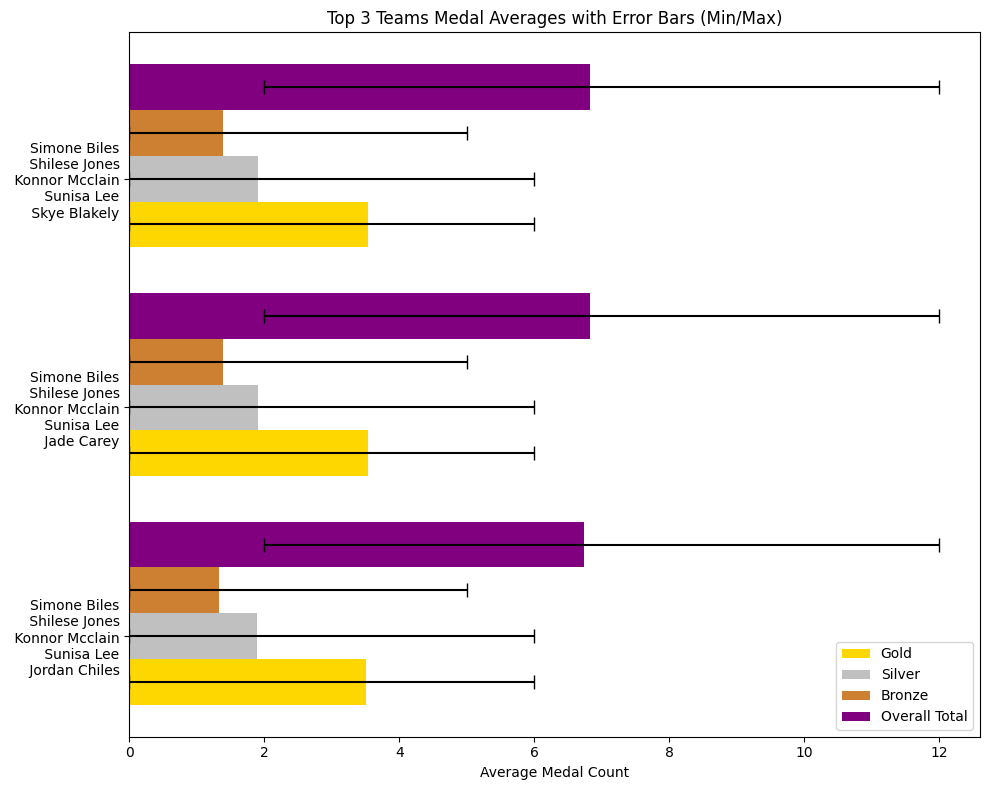

In [22]:
top5 = sorted_results.head(3).copy()[::-1]
x_labels = [", ".join(combo) for combo in top5['combination']]
x_labels = ["\n".join(combo.split(",")) for combo in x_labels[::-1]]
x = np.arange(len(x_labels))
width = 0.25  
overall_gold_err_lower = top5['overall_gold'] - top5['min_gold']
overall_gold_err_upper = top5['max_gold'] - top5['overall_gold']
silver_err_lower = top5['overall_silver'] - top5['min_silver']
silver_err_upper = top5['max_silver'] - top5['overall_silver']
bronze_err_lower = top5['overall_bronze'] - top5['min_bronze']
bronze_err_upper = top5['max_bronze'] - top5['overall_bronze']
overall_err_lower = top5['overall_total'] - top5['min_overall']
overall_err_upper = top5['max_overall'] - top5['overall_total']

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32', 'Overall':'purple'}
width = 0.2
ax.barh(x - width, top5['overall_gold'], height=width, label='Gold',
        xerr=[overall_gold_err_lower, overall_gold_err_upper], capsize=5, color=colors['Gold'])
ax.barh(x, top5['overall_silver'], height=width, label='Silver',
        xerr=[silver_err_lower, silver_err_upper], capsize=5, color=colors['Silver'])

ax.barh(x + width, top5['overall_bronze'], height=width, label='Bronze',
        xerr=[bronze_err_lower, bronze_err_upper], capsize=5, color=colors['Bronze'])

ax.barh(x + 2* width, top5['overall_total'], height=width, label='Overall Total',
        xerr=[overall_err_lower, overall_err_upper], capsize=5, color=colors['Overall'])

ax.set_yticks(x)
ax.set_yticklabels(x_labels)

ax.set_xlabel('Average Medal Count')
ax.set_title('Top 3 Teams Medal Averages with Error Bars (Min/Max)')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

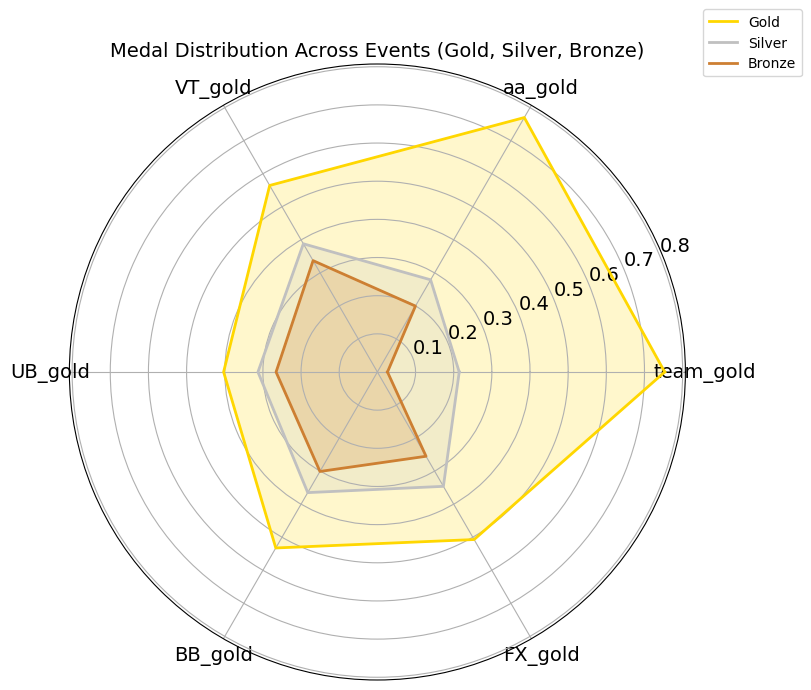

In [23]:
data = sorted_results.head(1)

categories = ['team_gold', 'aa_gold', 'VT_gold', 'UB_gold', 'BB_gold', 'FX_gold']

gold_values = data[categories].mean().values
silver_values = data[[c.replace('gold', 'silver') for c in categories]].mean().values
bronze_values = data[[c.replace('gold', 'bronze') for c in categories]].mean().values

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

gold_values = np.append(gold_values, gold_values[0])
silver_values = np.append(silver_values, silver_values[0])
bronze_values = np.append(bronze_values, bronze_values[0])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.plot(angles, gold_values, color='gold', linewidth=2, label='Gold')
ax.fill(angles, gold_values, color='gold', alpha=0.2)

ax.plot(angles, silver_values, color='silver', linewidth=2, label='Silver')
ax.fill(angles, silver_values, color='silver', alpha=0.2)

ax.plot(angles, bronze_values, color='#cd7f32', linewidth=2, label='Bronze')
ax.fill(angles, bronze_values, color='#cd7f32', alpha=0.2)

plt.xticks(angles[:-1], categories, fontsize=14)  
plt.title('Medal Distribution Across Events (Gold, Silver, Bronze)', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()

## **Future Outlook**  

### **1. Potential Improvements**  
- **Tokyo 2021 Data Integration**: Merging Tokyo 2021 data led to decreased accuracy, which requires further refinement to ensure better alignment with current performance metrics.  
- **Refined Handling of Scores**: Separating **D-score (difficulty)**, **E-score (execution)**, and **penalties** could improve the model's precision and provide a more granular analysis of gymnasts' performances.  
- **Data Gaps for Emerging Talents**: The current dataset only covers competitions up to 2023, missing rising stars like **Hezly Rivera**. Additional data collection is needed to incorporate emerging talents and ensure comprehensive coverage.  

### **2. Applications**  
- **Broad Predictive Scope**: The model can be extended to predict performance across different **countries**, **genders**, and **competitions**, such as the **2028 Los Angeles Olympics**.  
- **Comprehensive Performance Analysis**: The model optimizes **lineup selection**, identifies **national strengths** in specific apparatus, and projects **potential medal outcomes**, making it a valuable tool for strategic planning and decision-making.  

**Note:** Future iterations of the model will focus on addressing these improvements and expanding its applications to enhance its predictive accuracy and utility in the field of gymnastics performance analysis.  